In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchsummary import summary
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [ ]:
class AlexNet(nn.Module):
    def __init__(self, eta, n_iter, batch_size, random_state):
        super().__init__()
        self.eta = eta
        self.n_iter = n_iter
        self.batch_size = batch_size
        self.random_state = random_state

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Using device: {self.device}')

        self.conv1    = nn.Conv2d(in_channels=3,   out_channels=32,  kernel_size=3, stride=1, padding=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2    = nn.Conv2d(in_channels=32,  out_channels=64,  kernel_size=3, stride=1, padding=1)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3    = nn.Conv2d(in_channels=64,  out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv4    = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv5    = nn.Conv2d(in_channels=128, out_channels=64,  kernel_size=3, stride=1, padding=1)

        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(in_features=4096, out_features=128)
        self.fc2     = nn.Linear(in_features=128,  out_features=64)
        self.output  = nn.Linear(in_features=64,   out_features=10)

        self.dropout = nn.Dropout(p=0.5)   # defined here, not used in Part A forward

        self.train_losses_     = []
        self.train_accuracies_ = []
        self.val_losses_       = []
        self.val_accuracies_   = []

        self.to(self.device)

    def forward(self, x):
        x = self.maxpool1(torch.relu(self.conv1(x)))   # (N, 32, 16, 16)
        x = self.maxpool2(torch.relu(self.conv2(x)))   # (N, 64,  8,  8)
        x = torch.relu(self.conv3(x))                  # (N, 128, 8,  8)
        x = torch.relu(self.conv4(x))                  # (N, 128, 8,  8)
        x = torch.relu(self.conv5(x))                  # (N, 64,  8,  8)
        x = self.flatten(x)                            # (N, 4096)
        x = torch.relu(self.fc1(x))                    # (N, 128)
        x = torch.relu(self.fc2(x))                    # (N, 64)
        x = self.output(x)                             # (N, 10)
        return x

    def iter_minibatch(self, X, y):
        dataset    = TensorDataset(X, y)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        return dataloader

    def fit(self, X, y, X_val, y_val):
        torch.manual_seed(self.random_state)

        # Bug 2 fixed: added momentum and weight_decay
        optimizer    = optim.SGD(self.parameters(), lr=self.eta,
                                 momentum=0.9, weight_decay=1e-4)
        criterion    = nn.CrossEntropyLoss()
        train_loader = self.iter_minibatch(X, y)

        for epoch in range(self.n_iter):
            self.train()

            running_loss = 0.0
            correct      = 0
            total        = 0

            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                optimizer.zero_grad()
                y_hat = self(X_batch)
                loss  = criterion(y_hat, y_batch)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                preds         = y_hat.argmax(dim=1)
                correct      += (preds == y_batch).sum().item()
                total        += y_batch.size(0)

            epoch_loss = running_loss / len(train_loader)
            epoch_acc  = 100.0 * correct / total        # Bug 3 fixed: percentage

            self.train_losses_.append(epoch_loss)       # Bug 1 fixed: appended once
            self.train_accuracies_.append(epoch_acc)

            val_loss, val_acc = self._evaluate(X_val, y_val, criterion)
            self.val_losses_.append(val_loss)
            self.val_accuracies_.append(val_acc)

            print(f'Epoch {epoch+1:>3}/{self.n_iter} | '
                  f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

        return self

    def _evaluate(self, X, y, criterion):
        loader = self.iter_minibatch(X, y)
        self.eval()

        running_loss = 0.0
        correct      = 0
        total        = 0

        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                outputs = self(X_batch)
                loss    = criterion(outputs, y_batch)

                running_loss += loss.item()
                _, predicted  = torch.max(outputs, dim=1)
                total        += y_batch.size(0)
                correct      += (predicted == y_batch).sum().item()

        avg_loss = running_loss / len(loader)
        accuracy = 100.0 * correct / total
        return avg_loss, accuracy

    def predict(self, X):
        # Bug 4 fixed: handle numpy input
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        self.eval()
        with torch.no_grad():
            X        = X.to(self.device)
            logits   = self(X)
            _, preds = torch.max(logits, dim=1)
        return preds.cpu().numpy()

    def accuracy(self, X, y):
        # Bug 4 fixed: handle tensor y
        if isinstance(y, torch.Tensor):
            y = y.numpy()
        preds = self.predict(X)
        return 100.0 * np.mean(preds == y)

In [ ]:

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=test_transform)

# ── Split trainset → 45k train / 5k val ──────────────────────────────────────
train_size = 45000
val_size   = 5000

train_subset, val_subset = random_split(
    trainset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
def dataset_to_tensors(subset):
    """Load an entire Dataset subset into memory as tensors."""
    loader = DataLoader(subset, batch_size=len(subset), shuffle=False)
    X, y = next(iter(loader))   # one giant batch = the whole subset
    return X, y

print("Loading train tensors...")
X_train, y_train = dataset_to_tensors(train_subset)

print("Loading val tensors...")
X_val, y_val     = dataset_to_tensors(val_subset)

print("Loading test tensors...")
X_test, y_test   = dataset_to_tensors(testset)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Loading train tensors...
Loading val tensors...
Loading test tensors...
Train: torch.Size([45000, 3, 32, 32]) | Val: torch.Size([5000, 3, 32, 32]) | Test: torch.Size([10000, 3, 32, 32])


In [ ]:
model_1a = AlexNet(eta=0.001, n_iter=100, batch_size=128, random_state=42)
print(f'model paramaters: {summary(model_1a, (3, 32, 32))}')

model_1a.fit(X_train, y_train,X_val, y_val)

test_acc = model_1a.accuracy(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

Using device: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
         MaxPool2d-2           [-1, 32, 16, 16]               0
            Conv2d-3           [-1, 64, 16, 16]          18,496
         MaxPool2d-4             [-1, 64, 8, 8]               0
            Conv2d-5            [-1, 128, 8, 8]          73,856
            Conv2d-6            [-1, 128, 8, 8]         147,584
            Conv2d-7             [-1, 64, 8, 8]          73,792
           Flatten-8                 [-1, 4096]               0
            Linear-9                  [-1, 128]         524,416
           Linear-10                   [-1, 64]           8,256
           Linear-11                   [-1, 10]             650
Total params: 847,946
Trainable params: 847,946
Non-trainable params: 0
----------------------------------------------------------------
Input size 

In [ ]:
def plot_curves(model, title):
  epochs = range(1, len(model.train_losses_) + 1)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  ax1.plot(epochs, model.train_losses_,
            label='Train loss',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax1.plot(epochs, model.val_losses_,
            label='Val loss',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax1.set_xlabel('Epoch', fontsize=12)
  ax1.set_ylabel('Cross-entropy loss', fontsize=12)
  ax1.set_title('Loss per epoch', fontsize=13)
  ax1.legend(fontsize=11)
  ax1.grid(True, alpha=0.3)

  ax2.plot(epochs, model.train_accuracies_,
            label='Train accuracy',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax2.plot(epochs, model.val_accuracies_,
            label='Val accuracy',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax2.set_xlabel('Epoch', fontsize=12)
  ax2.set_ylabel('Accuracy (%)', fontsize=12)
  ax2.set_title('Accuracy per epoch', fontsize=13)
  ax2.set_ylim(0, 100)
  ax2.legend(fontsize=11)
  ax2.grid(True, alpha=0.3)

  plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
  plt.tight_layout()
  plt.show()
  print("Saved: training_curves.png")



In [ ]:
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def plot_confusion_matrix(model, X_test, y_test, title='Confusion Matrix — AlexNet CIFAR-10 (Part A)'):
    # Get predictions from the model
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,           # show counts in each cell
        fmt='d',              # integer format
        cmap='Blues',         # blue colormap — darker = more examples
        xticklabels=CIFAR10_CLASSES,
        yticklabels=CIFAR10_CLASSES,
        linewidths=0.5,
        linecolor='gray',
        ax=ax
    )

    ax.set_xlabel('Predicted label', fontsize=12, labelpad=10)
    ax.set_ylabel('True label', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

    # Rotate x-axis labels so they don't overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix.png")

    # ── Print per-class accuracy ───────────────────────────────────────────
    print("\nPer-class accuracy:")
    print("-" * 35)
    for i, class_name in enumerate(CIFAR10_CLASSES):
        class_total   = cm[i].sum()
        class_correct = cm[i, i]
        class_acc     = 100.0 * class_correct / class_total
        print(f"  {class_name:<12}: {class_correct:>4}/{class_total} = {class_acc:.1f}%")
    print("-" * 35)
    overall = 100.0 * np.diag(cm).sum() / cm.sum()
    print(f"  {'Overall':<12}: {overall:.2f}%")

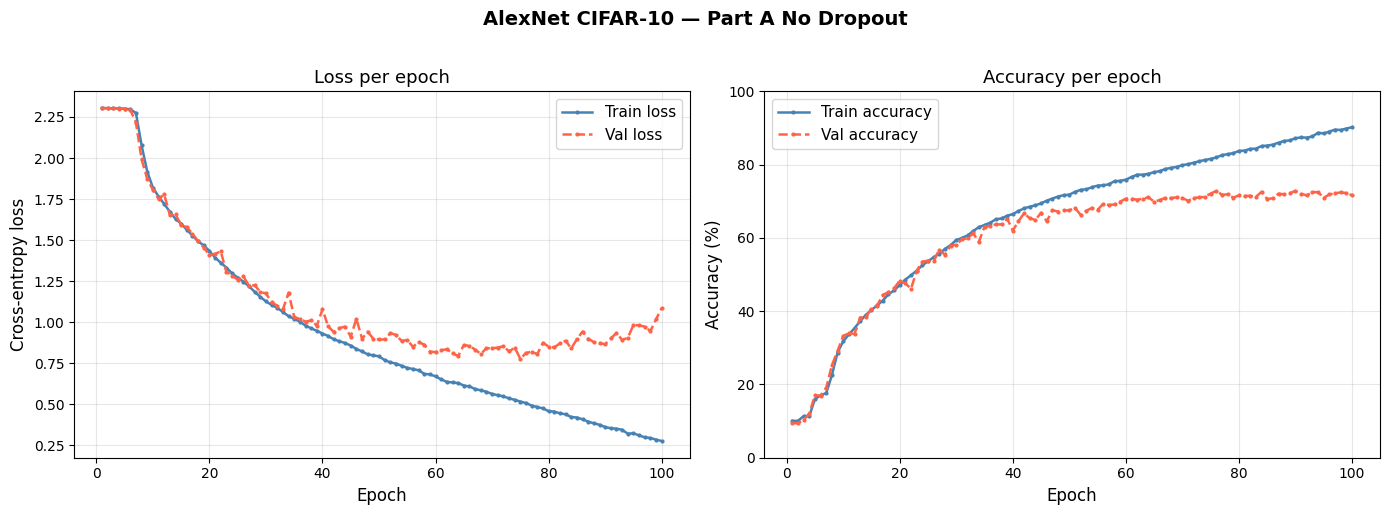

Saved: training_curves.png


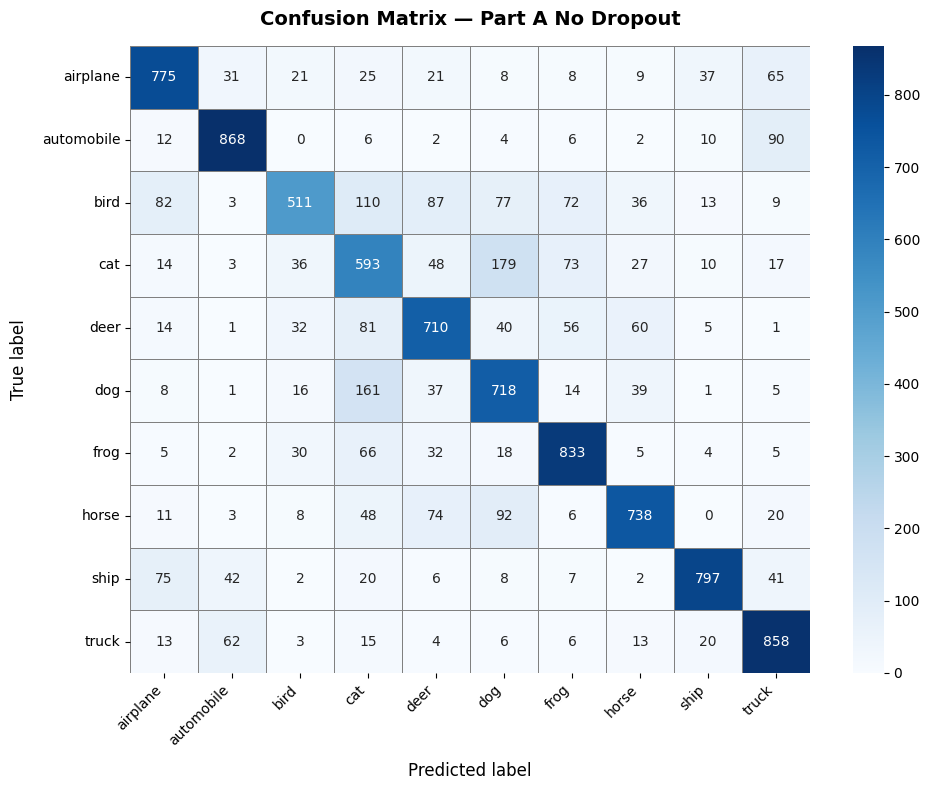

Saved: confusion_matrix.png

Per-class accuracy:
-----------------------------------
  airplane    :  775/1000 = 77.5%
  automobile  :  868/1000 = 86.8%
  bird        :  511/1000 = 51.1%
  cat         :  593/1000 = 59.3%
  deer        :  710/1000 = 71.0%
  dog         :  718/1000 = 71.8%
  frog        :  833/1000 = 83.3%
  horse       :  738/1000 = 73.8%
  ship        :  797/1000 = 79.7%
  truck       :  858/1000 = 85.8%
-----------------------------------
  Overall     : 74.01%


In [ ]:
# Paste or import the functions, then:
plot_curves(model_1a, title='AlexNet CIFAR-10 — Part A No Dropout')

plot_confusion_matrix(model_1a, X_test, y_test,
                      title='Confusion Matrix — Part A No Dropout')

In [ ]:
class AlexNetDropout(AlexNet):
    """
    AlexNet with dropout on FC layers.
    Inherits all methods from AlexNet — only __init__ and forward change.
    """
    def __init__(self, eta, n_iter, batch_size, random_state, dropout_rate=0.5):
        super().__init__(eta, n_iter, batch_size, random_state)

        # Override dropout with the specified rate
        self.dropout = nn.Dropout(p=dropout_rate)
        self.dropout_rate = dropout_rate

        print(f"Dropout rate: {dropout_rate}")

    def forward(self, x):
        x = self.maxpool1(torch.relu(self.conv1(x)))   # (N, 32, 16, 16)
        x = self.maxpool2(torch.relu(self.conv2(x)))   # (N, 64,  8,  8)
        x = torch.relu(self.conv3(x))                  # (N, 128, 8,  8)
        x = torch.relu(self.conv4(x))                  # (N, 128, 8,  8)
        x = torch.relu(self.conv5(x))                  # (N, 64,  8,  8)
        x = self.flatten(x)                            # (N, 4096)
        x = self.dropout(torch.relu(self.fc1(x)))      # (N, 128) + dropout
        x = self.dropout(torch.relu(self.fc2(x)))      # (N, 64)  + dropout
        x = self.output(x)                             # (N, 10)
        return x
torch.manual_seed(42)
print("fitting model with drop out rate set to 0.3--------")
# Part B — dropout p=0.3
model_b1 = AlexNetDropout(eta=0.001, n_iter=100, batch_size=128,
                           random_state=42, dropout_rate=0.3)
model_b1.fit(X_train, y_train, X_val, y_val)



fitting model with drop out rate set to 0.3--------
Using device: cuda
Dropout rate: 0.3
Epoch   1/100 | Loss: 2.3044 | Acc: 10.01% | Val Loss: 2.3040 | Val Acc: 9.42%
Epoch   2/100 | Loss: 2.3033 | Acc: 10.04% | Val Loss: 2.3036 | Val Acc: 9.42%
Epoch   3/100 | Loss: 2.3028 | Acc: 10.13% | Val Loss: 2.3032 | Val Acc: 9.42%
Epoch   4/100 | Loss: 2.3024 | Acc: 10.37% | Val Loss: 2.3026 | Val Acc: 9.64%
Epoch   5/100 | Loss: 2.3021 | Acc: 10.78% | Val Loss: 2.3021 | Val Acc: 10.22%
Epoch   6/100 | Loss: 2.3018 | Acc: 11.10% | Val Loss: 2.3017 | Val Acc: 10.12%
Epoch   7/100 | Loss: 2.3011 | Acc: 11.75% | Val Loss: 2.3008 | Val Acc: 14.98%
Epoch   8/100 | Loss: 2.2999 | Acc: 13.14% | Val Loss: 2.2989 | Val Acc: 15.68%
Epoch   9/100 | Loss: 2.2967 | Acc: 14.21% | Val Loss: 2.2924 | Val Acc: 17.26%
Epoch  10/100 | Loss: 2.2793 | Acc: 14.88% | Val Loss: 2.2436 | Val Acc: 17.62%
Epoch  11/100 | Loss: 2.1955 | Acc: 18.40% | Val Loss: 2.0909 | Val Acc: 26.22%
Epoch  12/100 | Loss: 2.0441 | Acc:

AlexNetDropout(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [ ]:
torch.manual_seed(42)
print("fitting model with drop out rate set to 0.5--------")

# Part B — dropout p=0.5
model_b2 = AlexNetDropout(eta=0.001, n_iter=100, batch_size=128,
                           random_state=42, dropout_rate=0.5)
model_b2.fit(X_train, y_train, X_val, y_val)

fitting model with drop out rate set to 0.5--------
Using device: cuda
Dropout rate: 0.5
Epoch   1/100 | Loss: 2.3046 | Acc: 9.92% | Val Loss: 2.3040 | Val Acc: 9.42%
Epoch   2/100 | Loss: 2.3034 | Acc: 10.06% | Val Loss: 2.3036 | Val Acc: 9.42%
Epoch   3/100 | Loss: 2.3029 | Acc: 10.20% | Val Loss: 2.3032 | Val Acc: 9.42%
Epoch   4/100 | Loss: 2.3026 | Acc: 10.00% | Val Loss: 2.3026 | Val Acc: 9.42%
Epoch   5/100 | Loss: 2.3022 | Acc: 10.62% | Val Loss: 2.3023 | Val Acc: 9.64%
Epoch   6/100 | Loss: 2.3020 | Acc: 10.75% | Val Loss: 2.3019 | Val Acc: 10.14%
Epoch   7/100 | Loss: 2.3016 | Acc: 11.08% | Val Loss: 2.3013 | Val Acc: 13.22%
Epoch   8/100 | Loss: 2.3008 | Acc: 11.55% | Val Loss: 2.3001 | Val Acc: 15.90%
Epoch   9/100 | Loss: 2.2993 | Acc: 12.82% | Val Loss: 2.2975 | Val Acc: 18.48%
Epoch  10/100 | Loss: 2.2949 | Acc: 13.66% | Val Loss: 2.2894 | Val Acc: 17.88%
Epoch  11/100 | Loss: 2.2780 | Acc: 14.45% | Val Loss: 2.2389 | Val Acc: 18.84%
Epoch  12/100 | Loss: 2.2030 | Acc: 1

AlexNetDropout(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

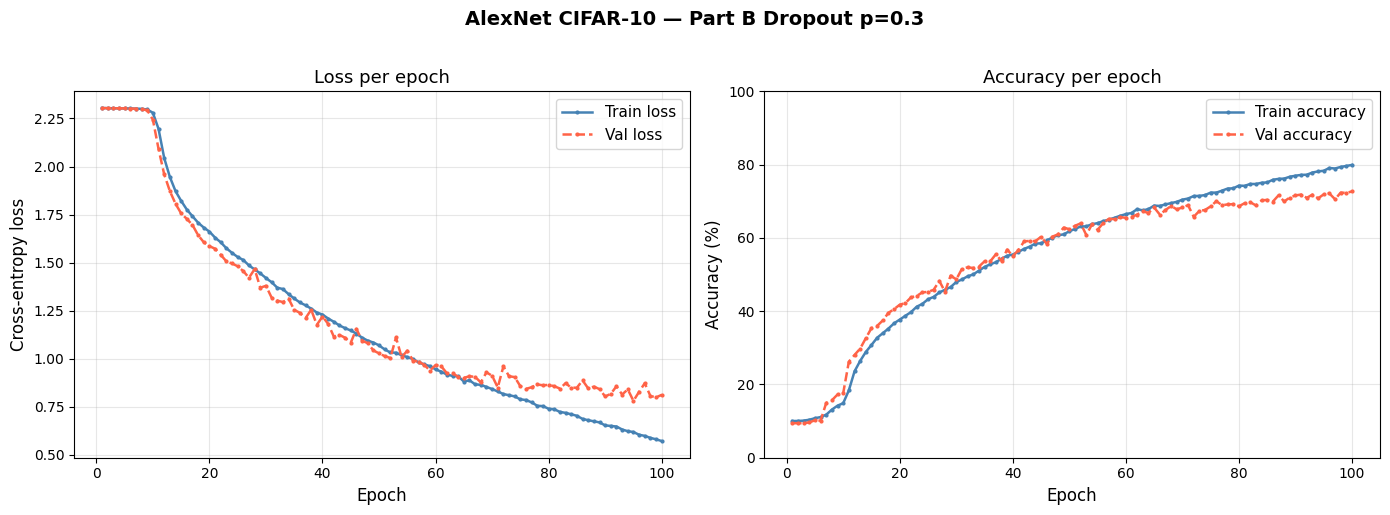

Saved: training_curves.png


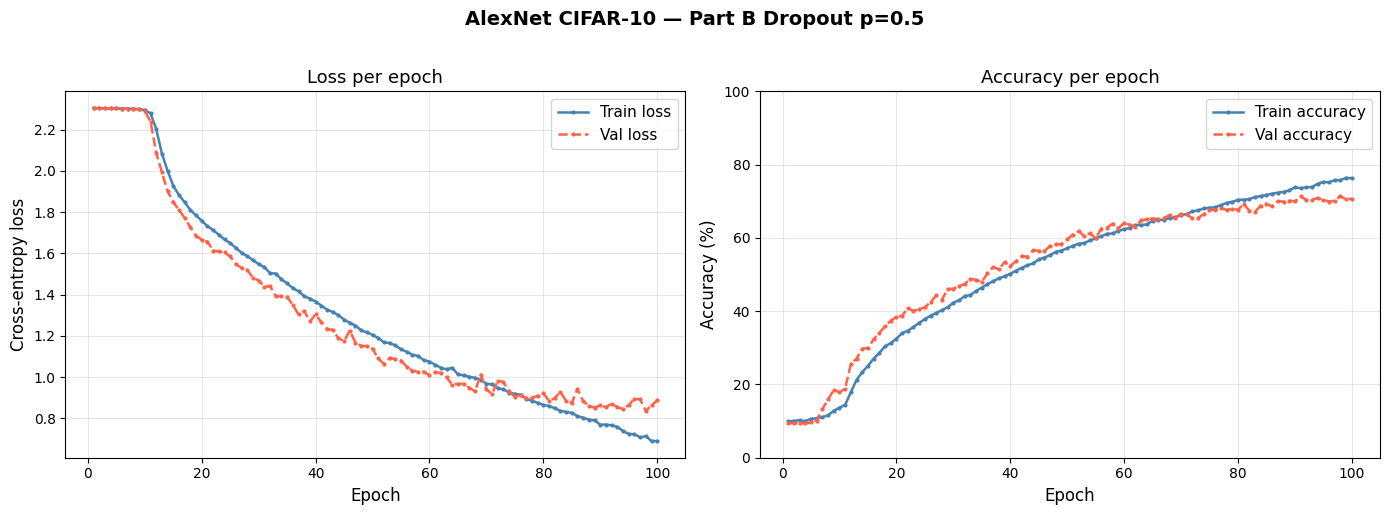

Saved: training_curves.png


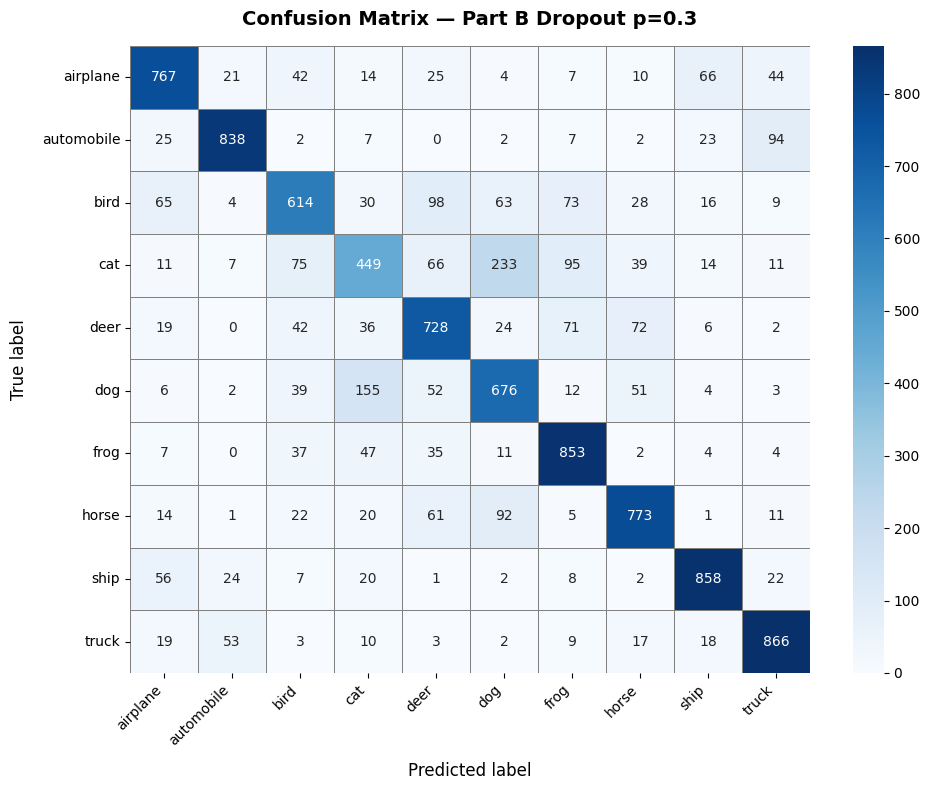

Saved: confusion_matrix.png

Per-class accuracy:
-----------------------------------
  airplane    :  767/1000 = 76.7%
  automobile  :  838/1000 = 83.8%
  bird        :  614/1000 = 61.4%
  cat         :  449/1000 = 44.9%
  deer        :  728/1000 = 72.8%
  dog         :  676/1000 = 67.6%
  frog        :  853/1000 = 85.3%
  horse       :  773/1000 = 77.3%
  ship        :  858/1000 = 85.8%
  truck       :  866/1000 = 86.6%
-----------------------------------
  Overall     : 74.22%


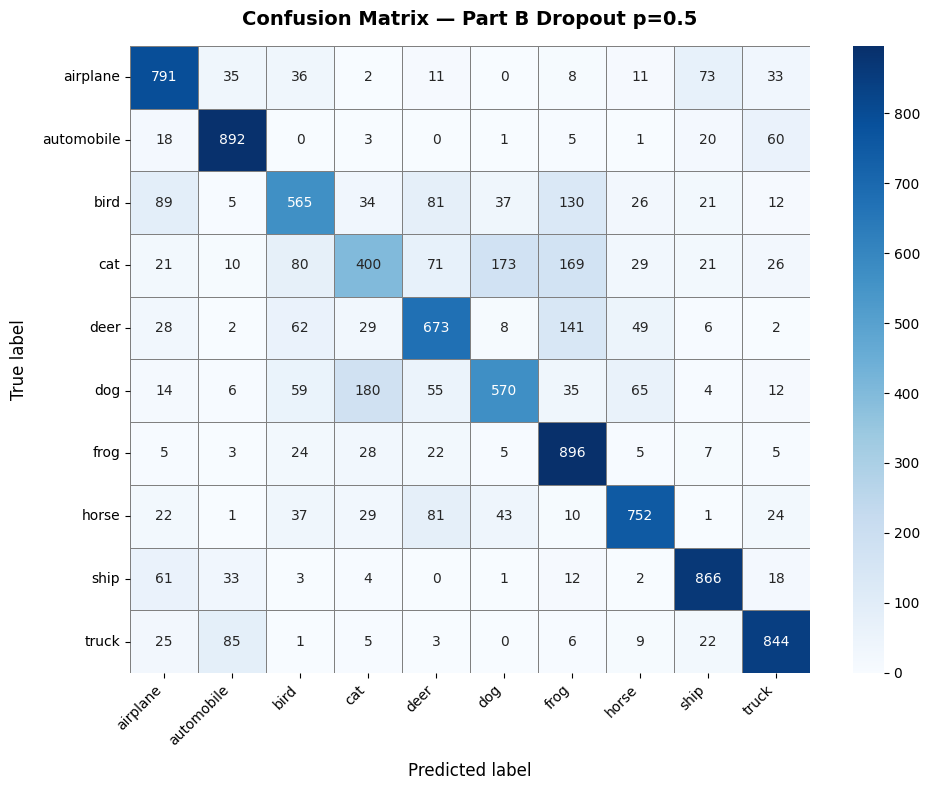

Saved: confusion_matrix.png

Per-class accuracy:
-----------------------------------
  airplane    :  791/1000 = 79.1%
  automobile  :  892/1000 = 89.2%
  bird        :  565/1000 = 56.5%
  cat         :  400/1000 = 40.0%
  deer        :  673/1000 = 67.3%
  dog         :  570/1000 = 57.0%
  frog        :  896/1000 = 89.6%
  horse       :  752/1000 = 75.2%
  ship        :  866/1000 = 86.6%
  truck       :  844/1000 = 84.4%
-----------------------------------
  Overall     : 72.49%


In [ ]:
plot_curves(model_b1, title='AlexNet CIFAR-10 — Part B Dropout p=0.3')
plot_curves(model_b2, title='AlexNet CIFAR-10 — Part B Dropout p=0.5')

plot_confusion_matrix(model_b1, X_test, y_test,
                      title='Confusion Matrix — Part B Dropout p=0.3')
plot_confusion_matrix(model_b2, X_test, y_test,
                      title='Confusion Matrix — Part B Dropout p=0.5')